  TD-MW-RPLS  –  Full Demo

[1] Generating synthetic industrial-process data …
    Saved → d:\Github\Machine-Learning-Studies\MLR\RPLS-MW-TD\synthetic_data.csv
Loaded 300 samples | 10 features | target='y'

[2] Config: window=20, lag=1, n_components=4

[3] Fitting TD-MW-RPLS (adaptive) …
    Initial δₑ = 1.053780
[TD-MW-RPLS] Samples processed : 279
             Model updates     : 275
             Final δₑ          : 0.730583
             RMSE              : 64.885437

[4] Comparing four model variants …
  PLS (static)                              RMSE=49.7880  updates=0
  MW-RPLS                                   RMSE=65.0325  updates=280
  TD-MW-RPLS                                RMSE=65.0325  updates=280
  TD-MW-RPLS + Adaptive                     RMSE=64.8854  updates=275

Summary table:
                Model  Max |rel error|  Min rel error    RMSE  Model updates
         PLS (static)           0.0768        -0.0483 49.7880              0
              MW-RPLS           0.0755   

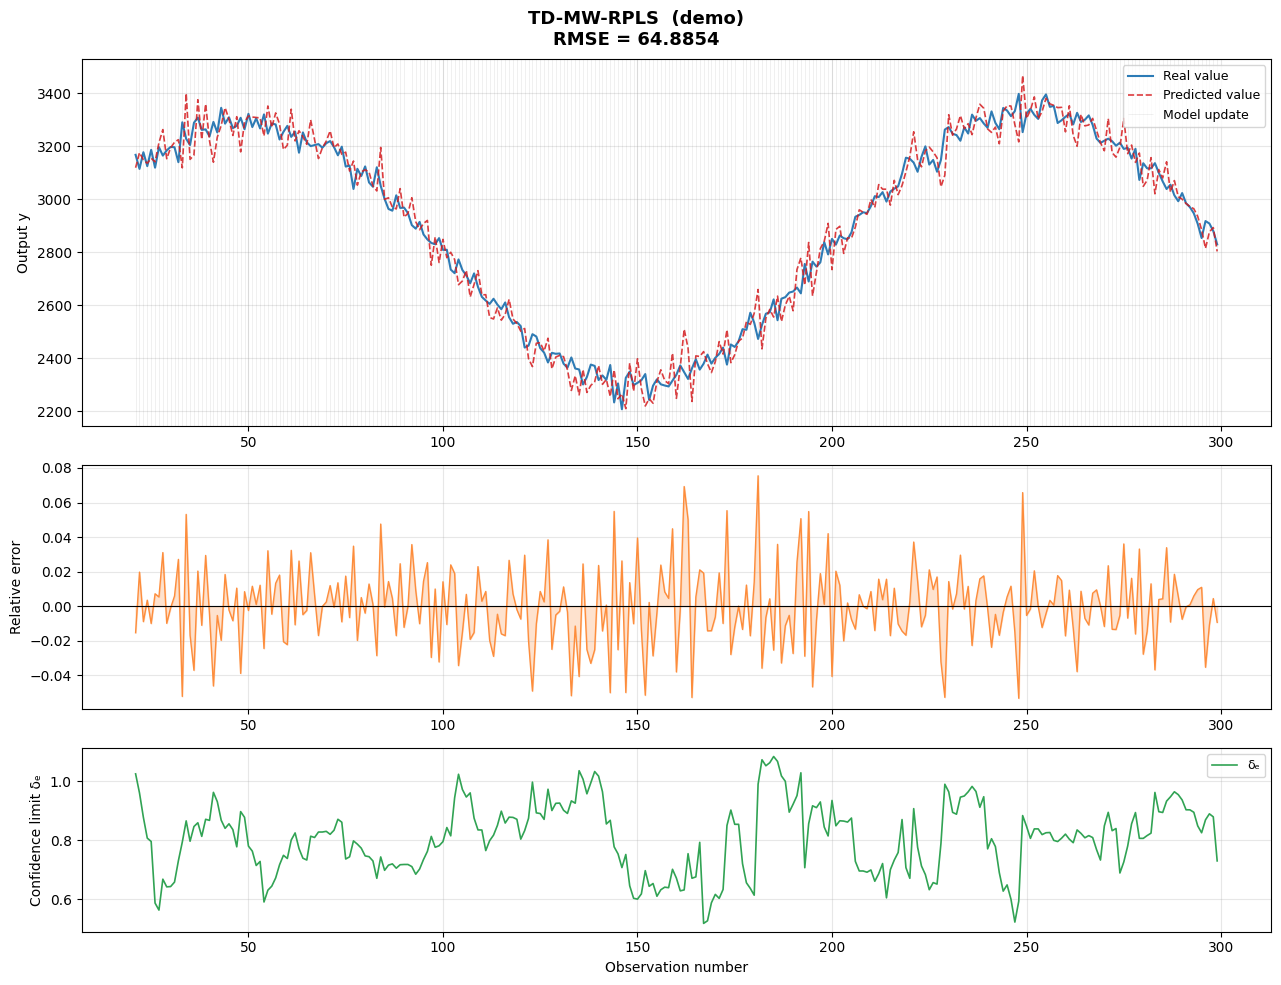

Plot saved → d:\Github\Machine-Learning-Studies\MLR\RPLS-MW-TD\td_mw_rpls_results.png

Outputs saved to: d:\Github\Machine-Learning-Studies\MLR\RPLS-MW-TD
  synthetic_data.csv | model_comparison.csv | td_mw_rpls_results.png


In [1]:
"""
TD-MW-RPLS: Time-Difference Moving-Window Recursive PLS
========================================================
Based on: Fu et al. (2017). Measurement Science and Technology, 28(4).

Requirements: numpy, pandas, scikit-learn, matplotlib
Usage:
    python td_mw_rpls.py                         # runs demo with synthetic data
    python td_mw_rpls.py --csv your_file.csv     # runs with your own data
"""

import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cross_decomposition import PLSRegression
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings("ignore")

# ── Output directory: same folder as this script (works on Windows & Linux) ──
OUTPUT_DIR = os.path.dirname(os.path.abspath(__file__)) if "__file__" in dir() \
             else os.getcwd()
os.makedirs(OUTPUT_DIR, exist_ok=True)

def _out(filename):
    return os.path.join(OUTPUT_DIR, filename)


# ─────────────────────────────────────────────────────────────────────────────
# TD_MW_RPLS class
# ─────────────────────────────────────────────────────────────────────────────

class TD_MW_RPLS:
    """
    Time-Difference Moving-Window Recursive PLS with Adaptive Model Updating.

    Parameters
    ----------
    window_size : int   – moving window length N
    n_components : int  – PLS latent variables a
    time_diff_lag : int – lag i for ΔX(t) = X(t) - X(t-i)
    adaptive_update : bool
        True  → update only when |error| > confidence limit  (paper's method)
        False → update on every new sample (standard MW-RPLS)
    """

    def __init__(self, window_size=20, n_components=4,
                 time_diff_lag=1, adaptive_update=True):
        self.window_size  = window_size
        self.n_components = n_components
        self.lag          = time_diff_lag
        self.adaptive     = adaptive_update

        self.model_      = None   # PLSRegression
        self.window_dX_  = []     # rolling list of ΔX row-arrays
        self.window_dy_  = []     # rolling list of Δy scalars
        self.confidence_ = None   # adaptive δ_e
        self.n_updates_  = 0

        self._mean_dX = None      # online mean (Eq. 14)
        self._var_dX  = None      # online variance (Eq. 15)

    # ── helpers ───────────────────────────────────────────────────────────────

    @staticmethod
    def _diff(arr, lag):
        return arr[lag:] - arr[:-lag]

    def _init_online_stats(self):
        """Lazy-init running mean/var from current window."""
        if self._mean_dX is None:
            dX = np.array(self.window_dX_)
            self._mean_dX = dX.mean(axis=0)
            self._var_dX  = np.maximum(dX.var(axis=0), 1e-8)

    def _update_online_stats(self, x_new):
        """Equations (14) and (15) applied element-wise."""
        self._init_online_stats()
        N = self.window_size
        new_mean = (N / (N+1)) * self._mean_dX + (1/(N+1)) * x_new
        new_var  = ((N-1)/N)   * self._var_dX  + ((N+1)/N**2) * (x_new - new_mean)**2
        self._mean_dX = new_mean
        self._var_dX  = np.maximum(new_var, 1e-8)

    def _window_arrays(self):
        """Return (dX_arr, dy_arr) from current window."""
        return np.array(self.window_dX_), np.array(self.window_dy_).reshape(-1, 1)

    def _standardise(self, dX, dy):
        mu_X, sd_X = dX.mean(0), dX.std(0) + 1e-8
        mu_y, sd_y = dy.mean(),  dy.std()  + 1e-8
        return (dX - mu_X)/sd_X, (dy - mu_y)/sd_y, mu_X, sd_X, mu_y, sd_y

    def _fit_pls(self):
        dX, dy = self._window_arrays()
        dX_s, dy_s, *_ = self._standardise(dX, dy)
        n_c = max(1, min(self.n_components, dX_s.shape[1], dX_s.shape[0]-1))
        pls = PLSRegression(n_components=n_c, max_iter=500)
        pls.fit(dX_s, dy_s)
        return pls

    def _compute_confidence(self):
        """Equation (16): δ_e = sqrt( Σresiduals² / (N-a-1) )"""
        dX, dy = self._window_arrays()
        dX_s, dy_s, *_ = self._standardise(dX, dy)
        res   = dy_s.ravel() - self.model_.predict(dX_s).ravel()
        denom = max(len(res) - self.model_.n_components - 1, 1)
        return float(np.sqrt((res**2).sum() / denom))

    def _predict_one(self, x_t, x_prev, y_prev):
        """
        ΔX = x(t)-x(t-lag)  →  standardise  →  PLS  →  back-transform
        ŷ(t) = y(t-lag) + Δŷ                              (Eq. 10)
        """
        dX, dy = self._window_arrays()
        mu_X, sd_X = dX.mean(0), dX.std(0) + 1e-8
        mu_y, sd_y = dy.mean(),  dy.std()  + 1e-8

        dx_s = ((x_t - x_prev) - mu_X) / sd_X
        dy_s = self.model_.predict(dx_s.reshape(1, -1))[0, 0]
        return float(y_prev + dy_s * sd_y + mu_y)

    # ── public API ────────────────────────────────────────────────────────────

    def fit(self, X, y):
        """Initial fit – Steps 1-4 of the paper."""
        X, y = np.asarray(X, float), np.asarray(y, float).ravel()
        need = self.window_size + self.lag
        if len(X) < need:
            raise ValueError(f"Need >= {need} samples, got {len(X)}")

        dX = self._diff(X[:need], self.lag)
        dy = self._diff(y[:need], self.lag)
        self.window_dX_ = list(dX)
        self.window_dy_ = list(dy)
        self.model_     = self._fit_pls()
        self.n_updates_ = 1
        self.confidence_= self._compute_confidence()
        return self

    def predict(self, X_new, X_prev, y_prev):
        """Batch offline prediction."""
        X_new  = np.asarray(X_new,  float)
        X_prev = np.asarray(X_prev, float)
        y_prev = np.asarray(y_prev, float).ravel()
        return np.array([
            self._predict_one(X_new[i], X_prev[i], y_prev[i])
            for i in range(len(X_new))
        ])

    def train_online(self, X, y, verbose=True):
        """
        Online sequential prediction + adaptive model updating – Steps 5-9.
        Returns dict: y_pred, y_true, update_flags, confidence_history, errors.
        """
        X, y = np.asarray(X, float), np.asarray(y, float).ravel()
        n    = len(X)

        y_pred_all   = np.full(n, np.nan)
        update_flags = np.zeros(n, bool)
        conf_history = np.full(n, np.nan)
        errors       = np.full(n, np.nan)

        start = self.window_size + self.lag

        for t in range(start, n):
            x_t, y_t     = X[t],       y[t]
            x_tm1, y_tm1 = X[t-self.lag], y[t-self.lag]

            # Step 7 – predict
            y_hat          = self._predict_one(x_t, x_tm1, y_tm1)
            y_pred_all[t]  = y_hat
            err            = abs(y_t - y_hat)
            errors[t]      = err

            # Steps 5-6 – slide window
            self._update_online_stats(x_t - x_tm1)
            self.window_dX_.append(x_t   - x_tm1)
            self.window_dy_.append(y_t   - y_tm1)
            if len(self.window_dX_) > self.window_size:
                self.window_dX_.pop(0)
                self.window_dy_.pop(0)

            # Step 9 – adaptive update decision
            if (not self.adaptive) or (err > self.confidence_):
                self.model_      = self._fit_pls()
                self.confidence_ = self._compute_confidence()
                self.n_updates_ += 1
                update_flags[t]  = True

            conf_history[t] = self.confidence_

        if verbose:
            valid = ~np.isnan(y_pred_all)
            rmse  = np.sqrt(mean_squared_error(y[valid], y_pred_all[valid]))
            print(f"[TD-MW-RPLS] Samples processed : {n - start}")
            print(f"             Model updates     : {self.n_updates_}")
            print(f"             Final δₑ          : {self.confidence_:.6f}")
            print(f"             RMSE              : {rmse:.6f}")

        return dict(y_pred=y_pred_all, y_true=y,
                    update_flags=update_flags,
                    confidence_history=conf_history,
                    errors=errors)


# ─────────────────────────────────────────────────────────────────────────────
# Data utilities
# ─────────────────────────────────────────────────────────────────────────────

def load_data(csv_path):
    """Read CSV (header: time, x1,...,xm, y) → X, y, feature_names."""
    df = pd.read_csv(csv_path)
    cols  = list(df.columns)
    y_col = cols[-1]
    x_cols= cols[1:-1]
    print(f"Loaded {len(df)} samples | {len(x_cols)} features | target='{y_col}'")
    return df[x_cols].values.astype(float), df[y_col].values.astype(float), x_cols


def generate_synthetic_data(n=300, m=10, seed=42):
    """Synthetic nonlinear time-varying process (mimics PTA / 4-CBA paper)."""
    rng   = np.random.default_rng(seed)
    t_idx = np.arange(n)
    drift = 500 * np.sin(2 * np.pi * t_idx / 200)
    X = np.cumsum(rng.standard_normal((n, m)) * 0.3, axis=0) \
        + rng.standard_normal((n, m)) * 0.1
    y = (2800 + 1.5*X[:,0] - 0.8*X[:,1] + 0.5*X[:,2] + 0.4*X[:,3]**2
         + drift + rng.standard_normal(n) * 30)
    df = pd.DataFrame(X, columns=[f"x{i+1}" for i in range(m)])
    df.insert(0, "time", t_idx)
    df["y"] = y
    return df


# ─────────────────────────────────────────────────────────────────────────────
# Plotting
# ─────────────────────────────────────────────────────────────────────────────

def plot_results(results, title_suffix="", save_path=None):
    """Three-panel plot: real vs pred | relative error | confidence limit."""
    y_true, y_pred = results["y_true"], results["y_pred"]
    conf, updates  = results["confidence_history"], results["update_flags"]

    valid   = ~np.isnan(y_pred)
    idx     = np.where(valid)[0]
    rmse    = np.sqrt(mean_squared_error(y_true[valid], y_pred[valid]))
    rel_err = (y_pred[valid] - y_true[valid]) / (np.abs(y_true[valid]) + 1e-8)

    fig, axes = plt.subplots(3, 1, figsize=(13, 10),
                             gridspec_kw={"height_ratios": [3, 2, 1.5]})
    fig.suptitle(f"TD-MW-RPLS  {title_suffix}\nRMSE = {rmse:.4f}",
                 fontsize=13, fontweight="bold")

    ax = axes[0]
    ax.plot(idx, y_true[valid], color="#2c7bb6", lw=1.5, label="Real value")
    ax.plot(idx, y_pred[valid], color="#d7191c", lw=1.2, ls="--",
            alpha=0.85, label="Predicted value")
    ylim = ax.get_ylim()
    ax.vlines(np.where(updates)[0], *ylim, color="gray", alpha=0.12, lw=0.7,
              label="Model update")
    ax.set_ylim(ylim); ax.set_ylabel("Output y")
    ax.legend(loc="upper right", fontsize=9); ax.grid(alpha=0.3)

    ax2 = axes[1]
    ax2.plot(idx, rel_err, color="#fd8d3c", lw=1.0)
    ax2.axhline(0, color="black", lw=0.8)
    ax2.fill_between(idx, rel_err, 0, alpha=0.25, color="#fd8d3c")
    ax2.set_ylabel("Relative error"); ax2.grid(alpha=0.3)

    ax3 = axes[2]
    ax3.plot(idx, conf[valid], color="#31a354", lw=1.2, label="δₑ")
    ax3.set_ylabel("Confidence limit δₑ"); ax3.set_xlabel("Observation number")
    ax3.legend(fontsize=9); ax3.grid(alpha=0.3)

    plt.tight_layout()
    path = save_path or _out("td_mw_rpls_results.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.show()
    print(f"Plot saved → {path}")


# ─────────────────────────────────────────────────────────────────────────────
# Model comparison  (Table 2 from paper)
# ─────────────────────────────────────────────────────────────────────────────

def compare_models(X, y, window_size=20, n_components=4):
    lag, start = 1, window_size + 1
    rows = []
    for name, adaptive in [("PLS (static)", None),
                            ("MW-RPLS",      False),
                            ("TD-MW-RPLS",   False),
                            ("TD-MW-RPLS + Adaptive", True)]:
        if name == "PLS (static)":
            dX = X[lag:start] - X[:start-lag]
            dy = (y[lag:start] - y[:start-lag]).reshape(-1, 1)
            dX_s = (dX - dX.mean(0)) / (dX.std(0)+1e-8)
            dy_s = (dy - dy.mean())  / (dy.std() +1e-8)
            nc   = max(1, min(n_components, dX_s.shape[1], dX_s.shape[0]-1))
            pls  = PLSRegression(n_components=nc, max_iter=500).fit(dX_s, dy_s)
            preds = []
            for t in range(start, len(X)):
                dx_s = ((X[t]-X[t-lag]) - dX.mean(0)) / (dX.std(0)+1e-8)
                dp   = pls.predict(dx_s.reshape(1,-1))[0,0]*(dy.std()+1e-8)+dy.mean()
                preds.append(y[t-lag] + dp)
            y_true, y_pred, n_upd = y[start:], np.array(preds), 0
        else:
            m = TD_MW_RPLS(window_size=window_size, n_components=n_components,
                           time_diff_lag=lag, adaptive_update=bool(adaptive))
            m.fit(X, y)
            res = m.train_online(X, y, verbose=False)
            vld = ~np.isnan(res["y_pred"])
            y_true, y_pred, n_upd = res["y_true"][vld], res["y_pred"][vld], m.n_updates_

        rmse    = np.sqrt(mean_squared_error(y_true, y_pred))
        rel_err = (y_pred - y_true) / (np.abs(y_true)+1e-8)
        rows.append({"Model": name,
                     "Max |rel error|": round(float(np.max(np.abs(rel_err))), 4),
                     "Min rel error"  : round(float(np.min(rel_err)), 4),
                     "RMSE"           : round(rmse, 4),
                     "Model updates"  : n_upd})
        print(f"  {name:40s}  RMSE={rmse:.4f}  updates={n_upd}")
    return pd.DataFrame(rows)


# ─────────────────────────────────────────────────────────────────────────────
# Main
# ─────────────────────────────────────────────────────────────────────────────

if __name__ == "__main__":

    # Optional: pass --csv path/to/your/file.csv
    csv_arg = None
    if "--csv" in sys.argv:
        csv_arg = sys.argv[sys.argv.index("--csv") + 1]

    print("=" * 65)
    print("  TD-MW-RPLS  –  Full Demo")
    print("=" * 65)

    if csv_arg:
        print(f"\n[1] Loading data from: {csv_arg}")
        X, y, _ = load_data(csv_arg)
    else:
        print("\n[1] Generating synthetic industrial-process data …")
        df = generate_synthetic_data(n=300, m=10, seed=0)
        csv_path = _out("synthetic_data.csv")
        df.to_csv(csv_path, index=False)
        print(f"    Saved → {csv_path}")
        X, y, _ = load_data(csv_path)

    WINDOW, LAG, N_COMP = 20, 1, 4
    print(f"\n[2] Config: window={WINDOW}, lag={LAG}, n_components={N_COMP}")

    print("\n[3] Fitting TD-MW-RPLS (adaptive) …")
    model = TD_MW_RPLS(window_size=WINDOW, n_components=N_COMP,
                       time_diff_lag=LAG, adaptive_update=True)
    model.fit(X, y)
    print(f"    Initial δₑ = {model.confidence_:.6f}")
    results = model.train_online(X, y, verbose=True)

    print("\n[4] Comparing four model variants …")
    comp_df = compare_models(X, y, window_size=WINDOW, n_components=N_COMP)
    print("\nSummary table:")
    print(comp_df.to_string(index=False))
    comp_df.to_csv(_out("model_comparison.csv"), index=False)

    print("\n[5] Plotting …")
    plot_results(results, title_suffix="(demo)")

    print("\n" + "=" * 65)
    print(f"Outputs saved to: {OUTPUT_DIR}")
    print("  synthetic_data.csv | model_comparison.csv | td_mw_rpls_results.png")
